# 建立稳态纯度模型

In [1]:
import os,gzip,pickle
from utils.keys import Cols
import numpy as np
import pandas as pd
import torch
import math
import matplotlib
import matplotlib.pyplot as plt

# 设置字体
matplotlib.rcParams['font.family'] = 'Microsoft YaHei, Times New Roman'
# 全局设置字号
plt.rcParams.update({
    'font.size': 16,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 20,  # 坐标轴标签字号
    'xtick.labelsize': 20,  # x轴刻度标签字号
    'ytick.labelsize': 20,  # y轴刻度标签字号
    'legend.fontsize': 16  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

## 导入数据与数据预处理

In [2]:
with gzip.open(
    r'D:\Devs\Single_Stack_MLJ\data\processed\Test data Hyzenis\2.03-2.05纯度实验\02.03-05气体纯度-60s-1# gzip',
    'rb'
) as f:
    df_Hyzenis = pickle.load(f)

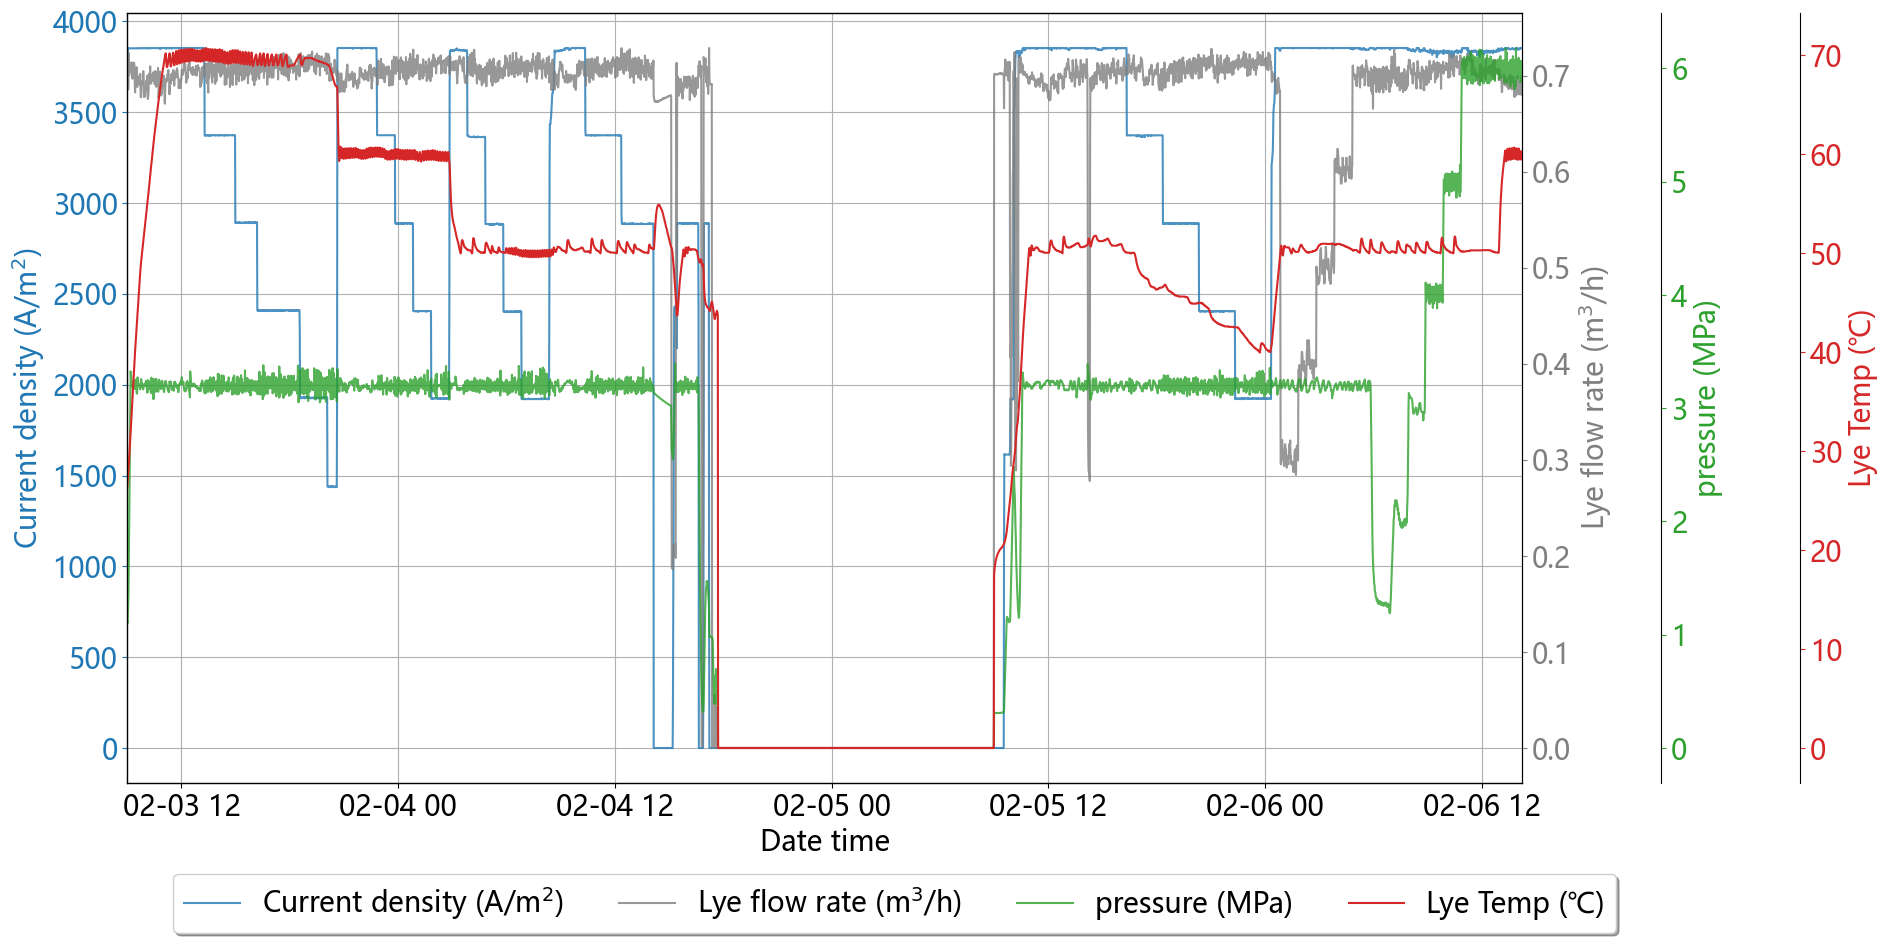

In [3]:
# 创建图表和子图
fig, ax1 = plt.subplots(figsize=(18, 10))
plt.grid(True)

# 绘制碱液流量曲线
ax1.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.current_density], c = '#1f77b4', alpha = 0.8,label = 'Current density (A/m$^2$)')
ax1.set_ylabel('Current density (A/m$^2$)', color='#1f77b4')
ax1.margins(x=0)  # 仅消除x轴边距
ax1.set_xlabel('Date time')
ax1.tick_params('y', colors='#1f77b4')
# ax1.set_ylim((1800, 4800))

# 创建第二个y轴
ax2 = ax1.twinx()

# 绘制第电流曲线
ax2.plot(df_Hyzenis[Cols.date_time], df_Hyzenis[Cols.lye_flow], alpha=0.8, c = '#7f7f7f', label = 'Lye flow rate (m$^3$/h)')
ax2.set_ylabel('Lye flow rate (m$^3$/h)', color='#7f7f7f')
ax2.tick_params('y', colors='#7f7f7f')
# ax2.set_ylim(0.2, 1.0)


# 创建第三个y轴
ax3 = ax1.twinx()

# 绘制电压曲线
ax3.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.pressure], c = '#2ca02c', alpha = 0.8,label = 'pressure (MPa)')
ax3.set_ylabel('pressure (MPa)', color='#2ca02c')
ax3.spines['right'].set_position(('outward', 100))
ax3.tick_params('y', colors='#2ca02c')
# ax3.set_ylim((1.7, 2.1))


# 创建第四个y轴
ax4 = ax1.twinx()

# 绘制出口温度曲线
ax4.plot(df_Hyzenis[Cols.date_time],df_Hyzenis[Cols.lye_temp], c = '#d62728', label = 'Lye Temp (℃)')
ax4.set_xlabel('Date time')
ax4.set_ylabel('Lye Temp (℃)', color='#d62728')
ax4.spines['right'].set_position(('outward', 200))
ax4.tick_params('y', colors='#d62728')
# ax4.set_ylim(30, 105)


# 添加图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3 + lines4, labels + labels2 + labels3 + labels4, loc='upper center',
           bbox_to_anchor=(0.55, -0.1), ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=20)

# 显示图表
plt.show()

In [4]:
# 两个时间段分别筛选
start_1, end_1 = '2026-02-03 12:00:00', '2026-02-04 12:00:00'
start_2, end_2 = '2026-02-05 12:00:00', '2026-02-06 12:00:00'

df_Hyzenis_01 = df_Hyzenis.query(
    f"@start_1 < {Cols.date_time} < @end_1"
).copy()

df_Hyzenis_02 = df_Hyzenis.query(
    f"@start_2 < {Cols.date_time} < @end_2"
).copy()

In [5]:
# 碱液流量进行平滑处理
df_Hyzenis_preprocessed_01 = df_Hyzenis_01.copy()
df_Hyzenis_preprocessed_02 = df_Hyzenis_02.copy()

df_Hyzenis_preprocessed_01[Cols.lye_flow] = df_Hyzenis_preprocessed_01[Cols.lye_flow].rolling(window=10, min_periods=10, center=True).mean()
df_Hyzenis_preprocessed_02[Cols.lye_flow] = df_Hyzenis_preprocessed_02[Cols.lye_flow].rolling(window=10, min_periods=10, center=True).mean()

### 选取稳态点

In [6]:
# 计算前后 5min 的氧中氢极差，筛选出极差小于 0.2 的行
window_size = 5
df_Hyzenis_preprocessed_chosen_01 = df_Hyzenis_preprocessed_01[
    df_Hyzenis_preprocessed_01[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min()) < 0.2
    ].copy()
df_Hyzenis_preprocessed_chosen_02 = df_Hyzenis_preprocessed_02[
    df_Hyzenis_preprocessed_02[Cols.temp_out].rolling(window=window_size, center=True, min_periods=1).apply(lambda x: x.max() - x.min()) < 0.2
    ].copy()

In [7]:
# 按行合并并重置索引
df_Hyzenis_processed = pd.concat([df_Hyzenis_preprocessed_chosen_01, df_Hyzenis_preprocessed_chosen_02], axis=0, ignore_index=True)

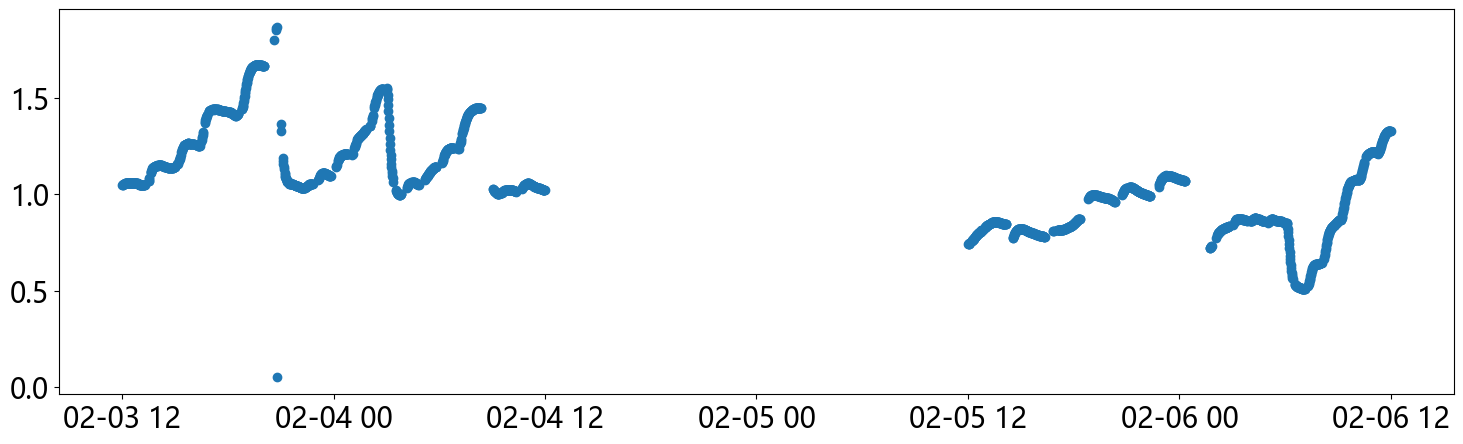

In [8]:
plt.figure(figsize=(18, 5))
plt.scatter(df_Hyzenis_processed[Cols.date_time], df_Hyzenis_processed[Cols.HTO])

## 构建纯度计算公式

In [9]:
def hto_model(params, temp_out, lye_temp, pressure, current_density):
    # 18个拟合参数
    C1,C2,C3,C4,C5,C6,C7,C8,C9,E1,E2,E3,E4,E5,E6,E7,E8,E9 = params

    temp_work = (temp_out + lye_temp) / 2.0
    
    # ✅ exp 单独提取，不影响张量计算
    exp_T = np.exp((C7 + C8*temp_work + C9*temp_work**2) / current_density)
    exp_p = np.exp((E7 + E8*pressure + E9*pressure**2) / current_density)
    
    # 温度项
    term1 = C1 + C2*temp_work + C3*temp_work**2
    term2 = (C4 + C5*temp_work + C6*temp_work**2) * exp_T
    part_T = term1 + term2
    
    # 压力项
    term3 = E1 + E2*pressure + E3*pressure**2
    term4 = (E4 + E5*pressure + E6*pressure**2) * exp_p
    part_p = term3 + term4
    
    # 总输出
    return part_T + part_p

In [10]:
feature_cols = [Cols.current_density, Cols.pressure, Cols.lye_temp, Cols.temp_out, Cols.lye_flow]
target_cols = [Cols.HTO]

statistics = df_Hyzenis_processed[feature_cols]
cell_voltage_observed = df_Hyzenis_processed[target_cols]

In [11]:
# 拟合前准备：张量构造与可微计算函数定义
torch.manual_seed(42)

# 构造训练张量
x = torch.tensor(statistics.values, dtype=torch.float32)
y = torch.tensor(cell_voltage_observed.values, dtype=torch.float32).squeeze(1)

# 去除缺失值行
valid_mask = torch.isfinite(x).all(dim=1) & torch.isfinite(y)
x = x[valid_mask]
y = y[valid_mask]

def hto_cal_torch(params, temp_out, lye_temp, pressure, current_density):
    C1,C2,C3,C4,C5,C6,C7,C8,C9,E1,E2,E3,E4,E5,E6,E7,E8,E9 = params

    temp_work = (temp_out + lye_temp) / 2.0

    # 截断指数输入，抑制 exp 溢出导致的训练不稳定
    exp_t_arg = (C7 + C8 * temp_work + C9 * temp_work**2) / (current_density + 1e-6)
    exp_p_arg = (E7 + E8 * pressure + E9 * pressure**2) / (current_density + 1e-6)
    exp_T = torch.exp(torch.clamp(exp_t_arg, min=-20.0, max=20.0))
    exp_p = torch.exp(torch.clamp(exp_p_arg, min=-20.0, max=20.0))

    term1 = C1 + C2 * temp_work + C3 * temp_work**2
    term2 = (C4 + C5 * temp_work + C6 * temp_work**2) * exp_T
    part_T = term1 + term2

    term3 = E1 + E2 * pressure + E3 * pressure**2
    term4 = (E4 + E5 * pressure + E6 * pressure**2) * exp_p
    part_p = term3 + term4

    return part_T + part_p

In [12]:
# 训练单元：稳健拟合 HTO 参数（训练/验证拆分 + 多次重启）

num_samples = x.shape[0]
if num_samples < 20:
    raise ValueError(f"样本量过小: {num_samples}，无法稳定训练")

# 训练/验证拆分
val_ratio = 0.2
perm = torch.randperm(num_samples)
val_size = max(1, int(num_samples * val_ratio))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

# 损失与训练配置
criterion = torch.nn.SmoothL1Loss(beta=0.05)
num_restarts = 3
num_epochs = 2500
l2_lambda = 1e-4

best_val_mse = float("inf")
best_params = None
best_train_mse = None

def compute_losses(x_batch, y_batch, params):
    pred = hto_cal_torch(
        params=params,
        temp_out=x_batch[:, 3],
        lye_temp=x_batch[:, 2],
        pressure=x_batch[:, 1],
        current_density=x_batch[:, 0],
    )
    valid_pred_mask = torch.isfinite(pred) & torch.isfinite(y_batch)
    if valid_pred_mask.sum() == 0:
        return None, None, None

    pred_valid = pred[valid_pred_mask]
    y_valid = y_batch[valid_pred_mask]
    mse = torch.mean((pred_valid - y_valid) ** 2)
    data_loss = criterion(pred_valid, y_valid)
    reg_loss = l2_lambda * torch.sum(params ** 2)
    total_loss = data_loss + reg_loss
    return total_loss, mse, pred_valid.numel()

for restart in range(num_restarts):
    params = torch.nn.Parameter(torch.randn(18, dtype=torch.float32) * 5e-4)
    optimizer = torch.optim.Adam([params], lr=5e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=5e-5)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        train_loss, train_mse, n_train_valid = compute_losses(x_train, y_train, params)
        if train_loss is None:
            raise ValueError("训练集预测全部无效，请检查公式或数据范围")

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_([params], max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if (epoch + 1) % 500 == 0:
            with torch.no_grad():
                val_loss, val_mse, n_val_valid = compute_losses(x_val, y_val, params)
                if val_mse is None:
                    print(f"Restart {restart+1}, Epoch [{epoch+1}/{num_epochs}] -> 验证集无有效预测")
                else:
                    print(
                        f"Restart {restart+1}, Epoch [{epoch+1}/{num_epochs}] "
                        f"Train MSE: {train_mse.item():.8f}, Val MSE: {val_mse.item():.8f}, "
                        f"Valid(train/val): {n_train_valid}/{n_val_valid}"
                    )

    with torch.no_grad():
        _, final_train_mse, _ = compute_losses(x_train, y_train, params)
        _, final_val_mse, _ = compute_losses(x_val, y_val, params)

    if final_val_mse is not None and final_val_mse.item() < best_val_mse:
        best_val_mse = final_val_mse.item()
        best_train_mse = final_train_mse.item() if final_train_mse is not None else None
        best_params = params.detach().clone()

if best_params is None:
    raise RuntimeError("训练失败：所有重启都没有得到有效验证结果")

params_hto = best_params

print("\nBest fitted HTO coefficients (C1~E9):")
print(params_hto.cpu().numpy())
print(f"Best Train MSE: {best_train_mse:.8f}")
print(f"Best Val MSE:   {best_val_mse:.8f}")

with torch.no_grad():
    pred_all = hto_cal_torch(
        params=params_hto,
        temp_out=x[:, 3],
        lye_temp=x[:, 2],
        pressure=x[:, 1],
        current_density=x[:, 0],
    )
    valid_pred_mask = torch.isfinite(pred_all) & torch.isfinite(y)
    y_eval = y[valid_pred_mask]
    pred_eval = pred_all[valid_pred_mask]
    mse_hto = torch.mean((pred_eval - y_eval) ** 2).item()
    mae_hto = torch.mean(torch.abs(pred_eval - y_eval)).item()
    rmse_hto = mse_hto ** 0.5

print(f"Overall MSE(HTO)  = {mse_hto:.8f}")
print(f"Overall RMSE(HTO) = {rmse_hto:.8f}")
print(f"Overall MAE(HTO)  = {mae_hto:.8f}")

Restart 1, Epoch [500/2500] Train MSE: 103.69876862, Val MSE: 72.25502777, Valid(train/val): 1678/419
Restart 1, Epoch [1000/2500] Train MSE: 10.47455215, Val MSE: 0.10257086, Valid(train/val): 1678/419
Restart 1, Epoch [1500/2500] Train MSE: 0.77467030, Val MSE: 0.59749311, Valid(train/val): 1678/419
Restart 1, Epoch [2000/2500] Train MSE: 0.15515886, Val MSE: 0.02048111, Valid(train/val): 1678/419
Restart 1, Epoch [2500/2500] Train MSE: 0.01336155, Val MSE: 0.01007921, Valid(train/val): 1678/419
Restart 2, Epoch [500/2500] Train MSE: 24.17029762, Val MSE: 19.04467392, Valid(train/val): 1678/419
Restart 2, Epoch [1000/2500] Train MSE: 9.08264446, Val MSE: 7.05962801, Valid(train/val): 1678/419
Restart 2, Epoch [1500/2500] Train MSE: 0.52448416, Val MSE: 0.37645122, Valid(train/val): 1678/419
Restart 2, Epoch [2000/2500] Train MSE: 0.06334130, Val MSE: 0.01590536, Valid(train/val): 1678/419
Restart 2, Epoch [2500/2500] Train MSE: 0.01144813, Val MSE: 0.00933110, Valid(train/val): 1678/

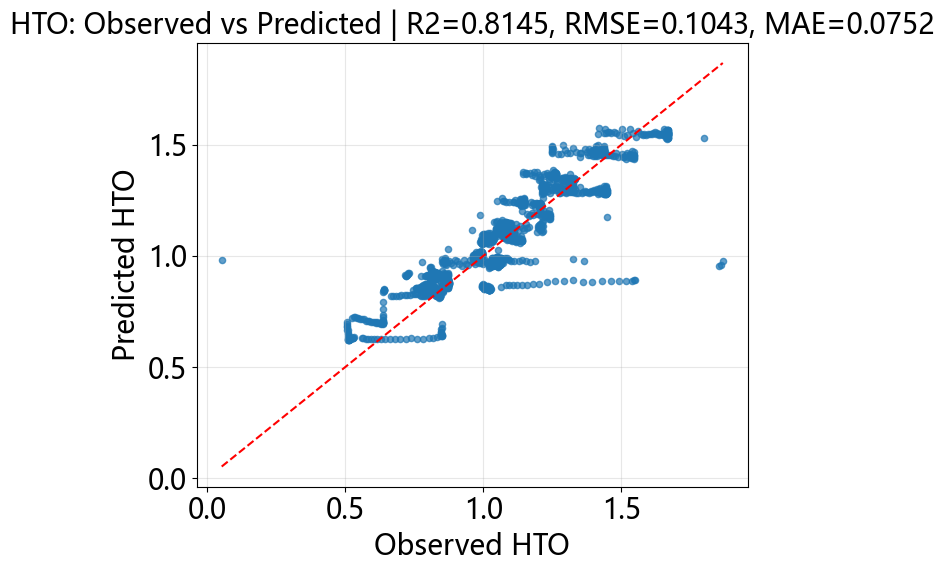

In [14]:
# 可视化单元：HTO 实测值与预测值对比（含 R2）
with torch.no_grad():
    pred_all = hto_cal_torch(
        params=params_hto,
        temp_out=x[:, 3],
        lye_temp=x[:, 2],
        pressure=x[:, 1],
        current_density=x[:, 0],
    )
    valid_pred_mask = torch.isfinite(pred_all) & torch.isfinite(y)
    y_eval = y[valid_pred_mask].cpu().numpy()
    pred_eval = pred_all[valid_pred_mask].cpu().numpy()

# 指标
mse = np.mean((pred_eval - y_eval) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(pred_eval - y_eval))
ss_res = np.sum((y_eval - pred_eval) ** 2)
ss_tot = np.sum((y_eval - np.mean(y_eval)) ** 2)
r2 = 1 - ss_res / (ss_tot + 1e-12)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(y_eval, pred_eval, alpha=0.7, s=20)
min_hto = min(y_eval.min(), pred_eval.min())
max_hto = max(y_eval.max(), pred_eval.max())
ax.plot([min_hto, max_hto], [min_hto, max_hto], 'r--', linewidth=1.5)
ax.set_title(f'HTO: Observed vs Predicted | R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}')
ax.set_xlabel('Observed HTO')
ax.set_ylabel('Predicted HTO')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()